# 2)  UNO Card Detection Pipeline

## Introduction

The goal of this part is to explain and visualize the different stages used to:

- detect half-UNO cards contours,
- filter contours that do not respect uno cards properties
- merge fragmented contours if applicatble to create full cards,
- compute bounding boxes for cards
- remove invalid detections,
- identify active player markers
- return cards and active player position, bounding box properties and color (for cards)

The notebook is organized as follows:

1. Contour extraction
2. Relevant contour selection
3. Contour interpolation
4. Distance computation
5. Contour merging
6. Bounding box verification
7. Nested contour removal
8. Active player marker detection
9. Final card extraction

---


# 0. Constants

For detection, we will be using several constants obtained from observation of the images, such as :

- The area of a half-Uno card, meaning the area of one colored part, is between () and (50000)pixels
- The aspect ratio of a half card is greater than (15)
- The active player marker can be :
    - yellow and circle (with an aspect ratio larger than 30)
    - black and rectangle (with 40000< rectangle area < 50000)
- Two halves of cards (colored areas) are separated by a minimal and maximal Euclidean distance of :
    - min_distance_threshold=250,
    - max_distance_threshold=500,
- A full card rectangle dimension is approximately 290x480 pixels 

# Imports

In [5]:
# LIBRARIES
from skimage.color import rgb2hsv, rgb2gray
from skimage.transform import rotate, resize, AffineTransform, warp
from sklearn.metrics.pairwise import euclidean_distances
from skimage.measure import regionprops
import matplotlib.image as mpimg

import os
import copy
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from src.Project_utils import *
from src.Project_cards_detection import *
from src.Project_segmentation import *

from sklearn.metrics import accuracy_score, f1_score
import cv2

In [6]:
#A ENLEVER POUR LE RAPPORT - CEST JOHANNE QUI REDIGE CA 

img = mpimg.imread("data/iapr-26-uno-vision-challenge/train_images/L1000853.jpg")

# Segmentation by color
color_masks = {
    'red': find_area_by_type(img, mode='red'),
    'blue': find_area_by_type(img, mode='blue'),
    'yellow': find_area_by_type(img, mode='yellow'),
    'green': find_area_by_type(img, mode='green'),
    'black': find_area_by_type(img, mode='black'),
}

mask_red = color_masks['red']

---

# 1. Contour Extraction

The first step consists of extracting contours from the segmented mask.

The function below uses OpenCV's contour extraction utilities and thresholds to keep interesting contours . Contours smaller than the minimum area are removed because they usually correspond to  tiny disconnected regions or leaves.

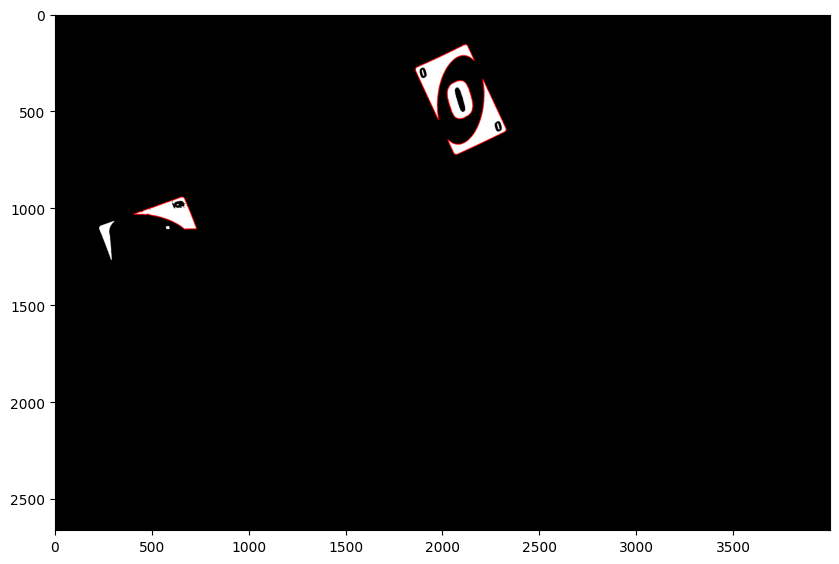

In [7]:
contours = find_contour_with_threshold(
    mask_red,
    arbitrary_minimal_area=18000,
    arbitrary_maximal_area=50000,
    save_plot=False,
    display_plot=True
)

The function:

- extracts contours,
- filters them according to area,
- optionally visualizes the results.


# 2. Relevant Contour Selection

After contour extraction, we select the most relevant contours based on aspect ratio (area divided by perimeter), implemented with OpenCV : cv2.contourArea(cnt) / cv2.arcLength(cnt, True). This part's objective is to filter out leaves and other irregular artifacts.

This step will leave us with many half cards, some of the center numbers and still some leaves 

Aspect ratios of the top 4 contours: [34.34682559101819, 26.81530183236167, 25.87041898674145, 25.68845129529166]
Areas of top aspect ratio contours: [19742.0, 23020.0, 31142.0, 30801.5]


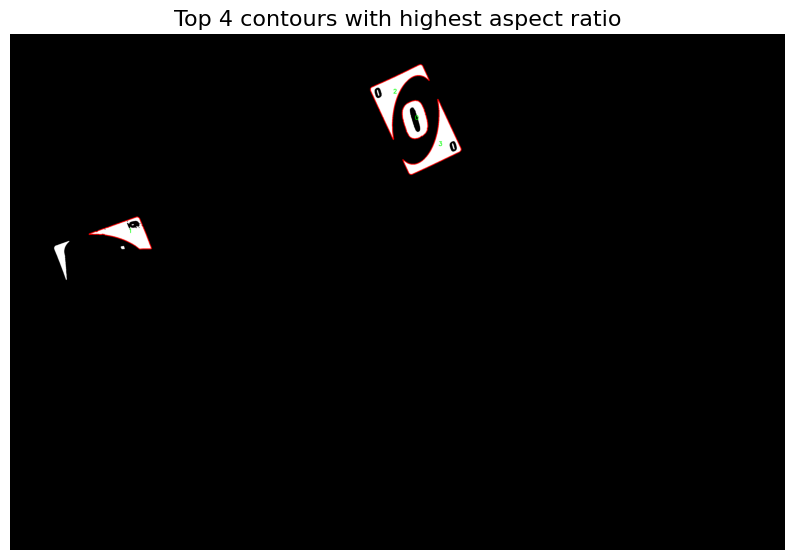

In [8]:
contours_high_ar = relevant_contours_finder(
    mask_red,
    contours,
    contours_to_consider=20,
    save_plot=False,
    show_plot =True,
    minimal_ar=15,
)

---

## Running Contour Interpolation

After reformatting, we run linear inerpolation on contours to ensure all contours have same number of points, and to reduce computational cost. 
Each contour is a fixed format (N, n_samples, 2)

In [10]:
new_contours = [c.reshape(-1, 2) for c in contours_high_ar]

contours_inter = linear_interpolation(
    new_contours,
    n_samples=25,
)

plot_interpolated_contours(mask_red, contours_inter)

---

## 3. Merging - Definition of distance

For each contour, we compute the distance as the minimal possible Euclidean between the closest points of each contour. Fragmented contours belonging to the same card should have relatively small distances. This matrix is later used to decide which contours should be merged.


In [11]:
distances = compute_distance_matrix(contours_inter)

## Merging - Merging Mask Calculation
 - Outputs a boolean mask of which contours are in the right range by measuring the distance
 - Corrects the mask by testing all merge. FOr each merge suggested, it measures its bounding box dimensions (box = cv2.minAreaRect())
 - Merges contour that will actually form a UNO card

In [13]:
merging_mask = merging_mask_calculator(
    contours_inter,
    distances,
    min_distance_threshold=250,
    max_distance_threshold=500,
)

In [14]:
tested_merging_mask = merging_verifyer(
    contours_inter,
    merging_mask,
    w=290,
    d=480,
    margin=40,
)

In [15]:
contours_merged = merge_contours_from_mask(
    contours_inter,
    merging_mask,
)

---

# 6. Bounding Box Verification HERE

Not all merged contours correspond to valid UNO cards, although some leaves stayed in the process

A geometric verification step is therefore applied.

Function used:

In [ ]:
merging_verifyer(...)

---

## Running Verification

---

## Explanation

Each contour is approximated using:

In [ ]:
cv2.minAreaRect(...)

This provides:

- center coordinates,
- width,
- height,
- rotation angle.

Only contours whose dimensions approximately match UNO card dimensions are kept.

This removes invalid merges.

---

# 7. Final Contour Reconstruction

After verification:

In [ ]:
contours_all = contours_merged + unmerged_contours

where:

In [ ]:
unmerged_contours = [
    contours_inter[i]
    for i in range(len(contours_inter))
    if not tested_merging_mask[i].any()
]

---

# 8. Nested Contour Removal

Some contours may become entirely contained inside others.

To remove duplicates:

In [ ]:
remove_nested_contours(...)

is applied.

---

## Running Nested Contour Removal

In [ ]:
contours_all = remove_nested_contours(contours_all)

---

## Explanation

Each contour is approximated by its rotated bounding rectangle.

A contour is removed if its bounding box lies entirely inside another one.

This avoids duplicate detections.

---

# 9. Bounding Box Visualization

The detected cards can be visualized using:

In [ ]:
plot_bounding_boxes(...)

---

## Running Visualization

In [ ]:
plot_bounding_boxes(
    mask=mask,
    bounding_boxes=bounding_boxes,
    color_tested=color,
    show_center=True,
    show_area=False,
    show_coordinates=True,
)

---

## Explanation

This function displays:

- rotated rectangles,
- contour centers,
- coordinates,
- optional area information.

This is extremely useful for debugging.

---

# 10. Active Player Marker Detection

The scene may contain active player markers.

These objects should not be classified as cards.

Function used:

In [ ]:
is_active_player_marker(...)

---

## Yellow Marker Detection

Yellow markers are identified using extreme aspect ratios.

Condition:

In [ ]:
aspect_ratio > yellow_min_aspect_ratio

Typical value:

In [ ]:
yellow_min_aspect_ratio = 30

---

## Black Marker Detection

Black markers are detected using:

- rectangularity,
- area constraints.

Rectangularity is defined as:

\[
\text{Rectangularity} = \frac{\text{Contour Area}}{\text{Bounding Box Area}}
\]

Typical constraints:

In [ ]:
rectangularity > 0.75
40000 < rect_area < 50000

---

# 11. Main Detection Pipeline

The complete detection pipeline is implemented in:

In [ ]:
main_detection(...)

---

## Running Full Detection

In [ ]:
all_cards, player_card = main_detection(
    img,
    color_masks,
    img_output_path,
    verbose=True,
)

---

## Returned Information

Each detected card is stored as:

In [ ]:
card_info = {
    'contour': contour,
    'color': color,
    'bbox': bbox,
    'centroid': (bbox[0][1], bbox[0][0]),
    'area': bbox[1][0] * bbox[1][1],
    'orientation': bbox[2],
    'value': None,
}

The pipeline extracts:

- card geometry,
- position,
- orientation,
- color,
- area.

These descriptors can later be used for:

- card recognition,
- game state reconstruction,
- card tracking.

---

# 12. Pipeline Summary

The complete pipeline follows this sequence:

```text
Segmentation Mask
        ↓
Contour Extraction
        ↓
Area Filtering
        ↓
Relevant Contour Selection
        ↓
Contour Interpolation
        ↓
Distance Matrix Computation
        ↓
Contour Merging
        ↓
Bounding Box Verification
        ↓
Nested Contour Removal
        ↓
Player Marker Detection
        ↓
Final Card Detection
```

---

# Conclusion

This detection pipeline combines:

- contour analysis,
- geometric filtering,
- interpolation,
- contour merging,
- rotated bounding box verification.

The approach is lightweight, interpretable, and robust for tabletop UNO scenes.

Its modular structure also makes it easy to:

- tune thresholds,
- improve robustness,
- integrate learned classifiers,
- extend to additional game elements.
